# Notebook: 05 Prediction
### Purpose: load a trained model, run inference, preview overlays, and optionally export a submission JSON.

In [1]:
import os
import sys


sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))
from src.data.augmentations import get_val_augmentations
from src.exploration.visualize import show_side_by_side
from src.models.zoo import MODEL_BUILDERS
from src.prediction.pipeline import Predictor
from src.prediction.submission import export_submission
from src.utils.config import Config
from src.utils.helpers import init_notebook, p
from src.utils.versioning import VersionManager


config = Config.load()

init_notebook(config.train.seed)



=== init_notebook ===
Done


#### Select model version

In [2]:
p("Models", MODEL_BUILDERS)
#config.show()
p("Batch", config.train.batch_size)
p("Epochs", config.train.epochs)
p("Learning Rate", config.train.learning_rate, precision = 9)
p("Image Size", config.train.image_size)

Models: 8 keys
  simple_cnn: <function create_simple_cnn at 0x000001173B7E7D80>
  unet: <function create_unet at 0x000001173B7E7CE0>
  smp_unet: <function create_smp_unet at 0x000001173B7E7C40>
  smp_fpn: <function create_smp_fpn at 0x00000117356CC400>
  smp_linknet: <function create_smp_linknet at 0x00000117356BFA60>
  smp_deeplabv3: <function create_smp_deeplabv3 at 0x000001173B6B58A0>
  smp_deeplabv3plus: <function create_smp_deeplabv3plus at 0x000001173B6B5B20>
  segformer: <function create_segformer at 0x0000011746317D80>
Batch: 1
Epochs: 2
Learning Rate: 0.010000000
Image Size: 32


In [3]:


model_name = "simple_cnn"

vm = VersionManager(config.paths.models)
version_dir = vm.find_latest()
model_path = version_dir / "best_model.pth"

predictor = Predictor(
        model_path = model_path,
        model_name = model_name,
        image_size = config.train.image_size,
)


[Info]: Loaded model weights from C:\github\Tree-Canopy-Detection\checkpoints\v002\best_model.pth


#### Run on evaluation folder

In [4]:
eval_dir = config.paths.eval_images
p("eval_dir", eval_dir)

transform = get_val_augmentations(config.train.image_size)

results = predictor.run_on_folder(eval_dir, transform = transform, num_samples = 10)


eval_dir: C:\github\Tree-Canopy-Detection\src\data\data1\evaluation_images


#### Visualizations Samples

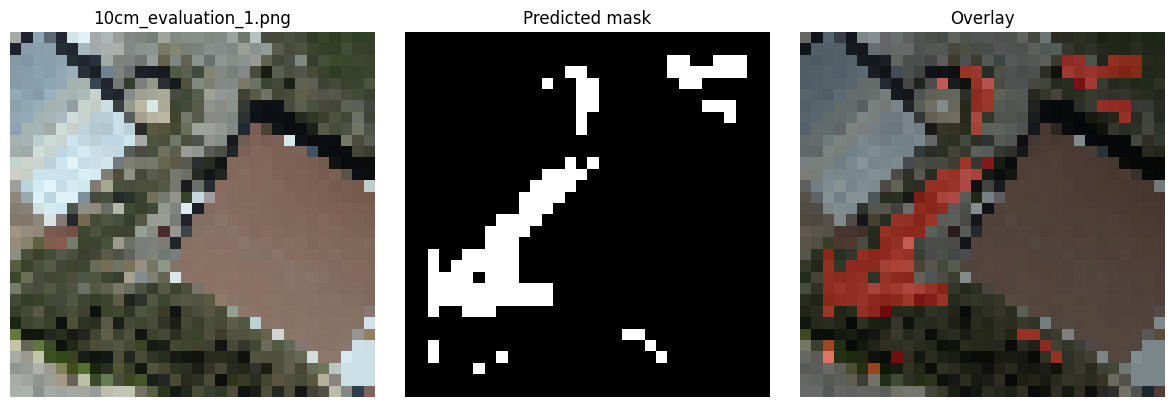

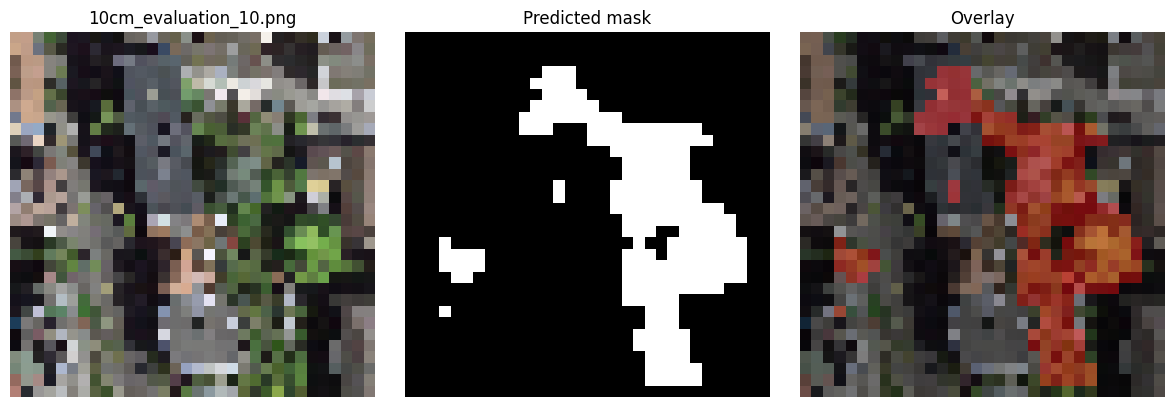

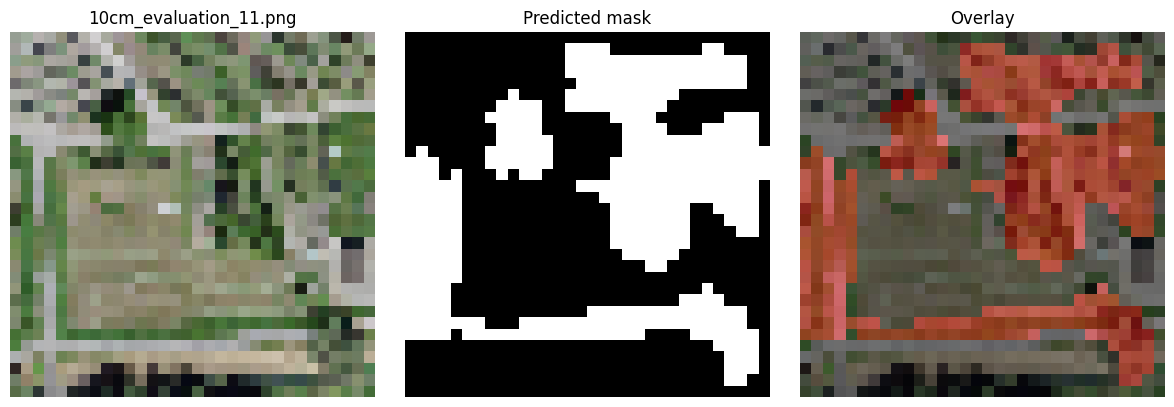

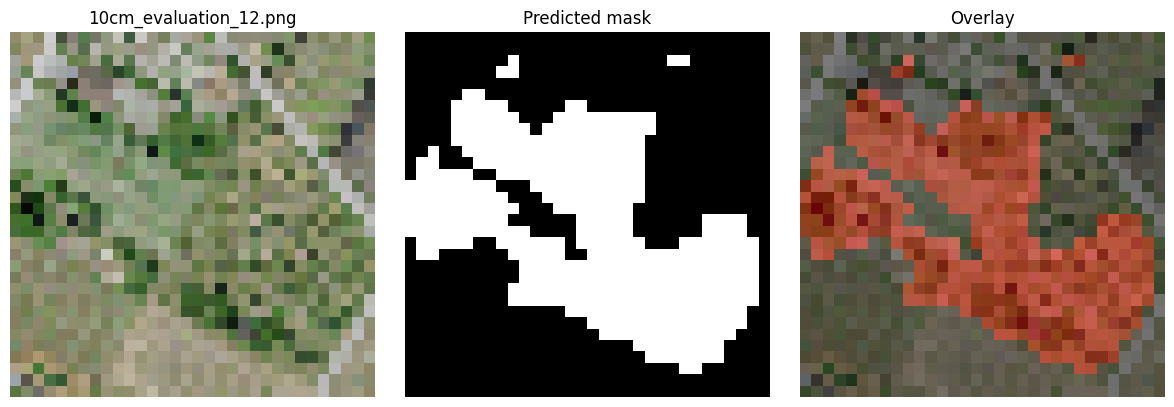

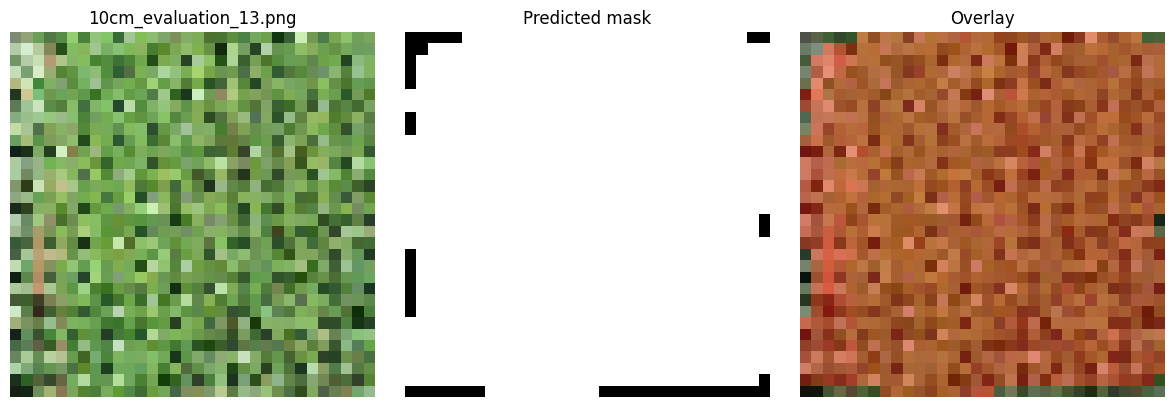

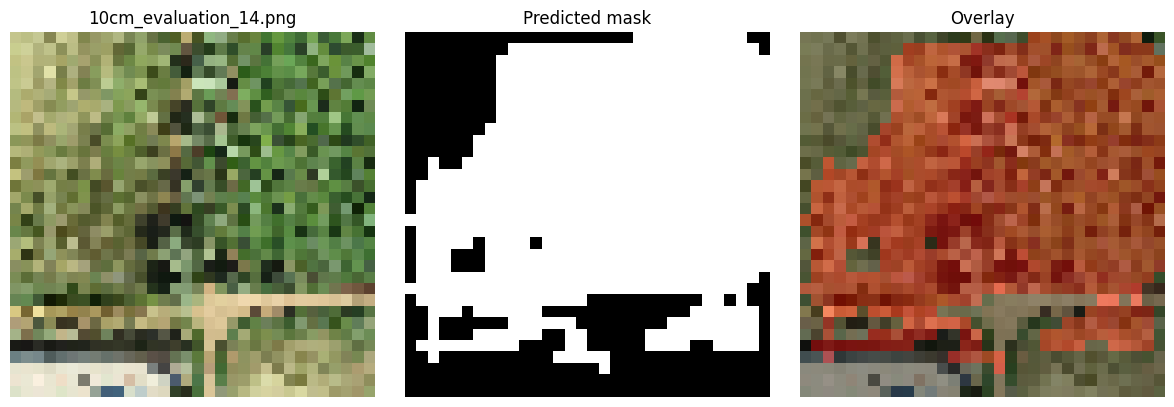

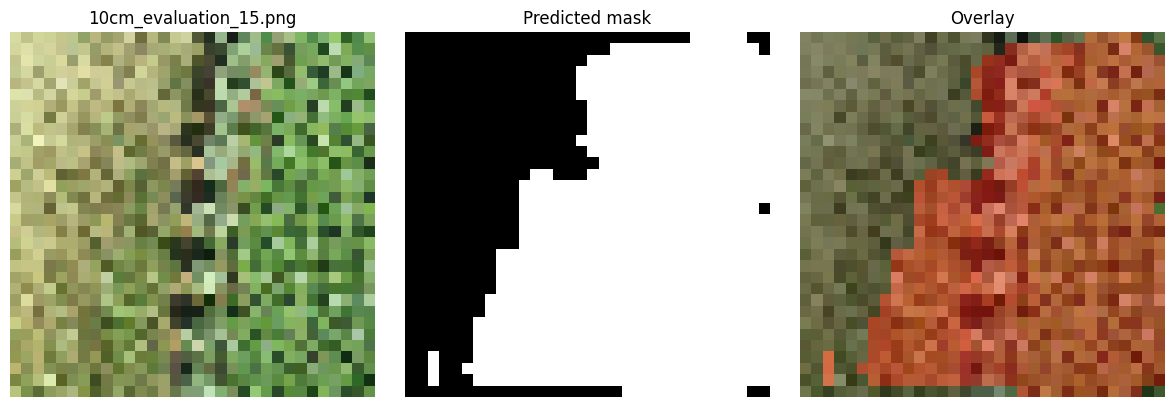

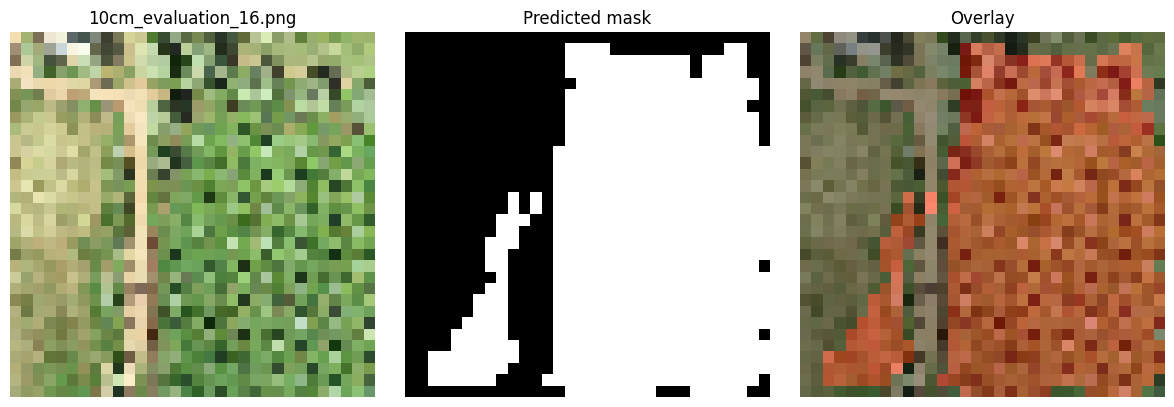

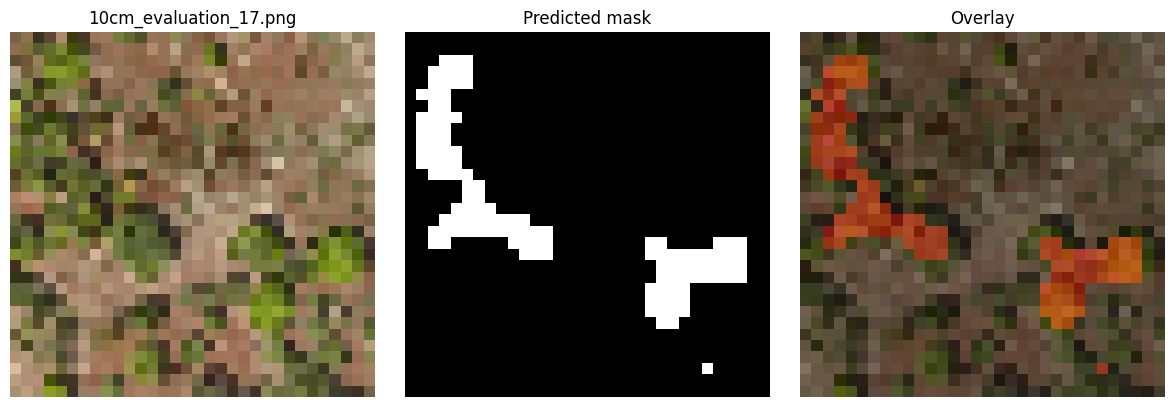

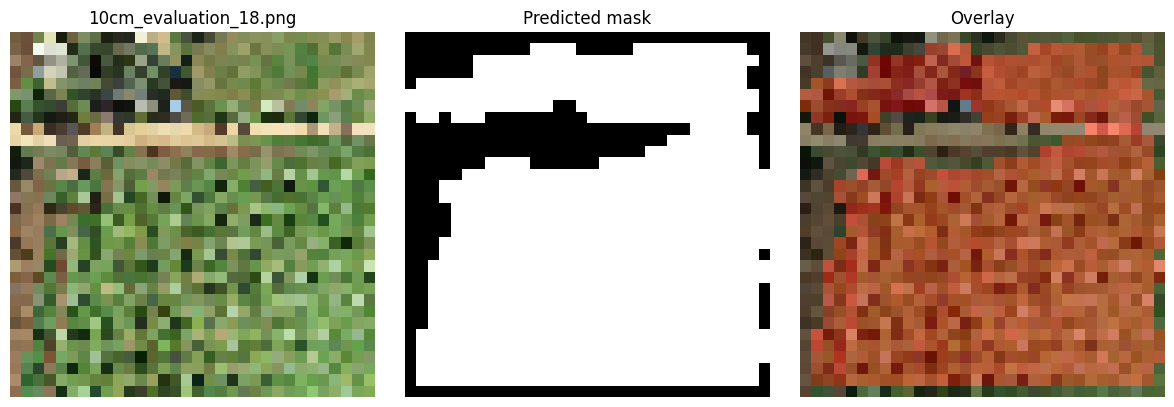

In [5]:
for r in results:
    img = r["image"]
    mask = r["mask"]
    overlay = r["overlay"]

    # show_image(img, r["name"])
    # show_mask(mask, "Predicted mask")
    # show_overlay(img, mask, 0.4, "Overlay")

    show_side_by_side(img, mask, overlay,
                      titles = [r["name"], "Predicted mask", "Overlay"],
                      cmaps = [None, "gray", None],
                      )



### Export submission file

In [6]:
vm = VersionManager(config.paths.models)
version_folder = vm.find_latest()

p("Exporting submission for version:", version_folder.name)

out_path = version_folder / "submission.json"
export_submission(results, out_path)
p("Submission Saved", out_path)

Exporting submission for version:: v002
=== Submission Export Complete ===
✓ Submission saved: C:\github\Tree-Canopy-Detection\checkpoints\v002\submission.json
✓ Total images: 10
✓ Total annotations: 13
✔ individual_tree annotations: 13
✔ group_of_trees annotations: 0
=== Sample ===
file_name: 10cm_evaluation_1.tif
width: 32
height: 32
scene_type: unknown
cm_resolution: 10
annotations: 1 polygons
  class: individual_tree
  confidence: 1
  segmentation points: 54
Submission Saved: C:\github\Tree-Canopy-Detection\checkpoints\v002\submission.json
